# Airframe Analysis (497R) - Samuel Nasman, 9 July 2024
## Introduction & Methods

*A GitHub wiki of unfamiliar terms can be found [here](https://github.com/samiamandyesican/497R/wiki). Special attention should be given to "Lifting Line Theory" and "Wing Geometry".*  

The purpose of this assignment is to obtain an understanding of the Vortex Lattice method and use it to gain understanding of airframe design, with particular attentions given to wing aspect ratio vs wing efficiency, vertical and horizontal tail volume ratio vs stability derivatives, as well as the limitations of VLM (Vortex Lattice Method). 

Initially, I will study the theory as explained in the ME EN 515 Text and complete several examples in the documentation for VortexLattice.jl. 

Next, I will use VortexLattice.jl to explore the effects of wing aspect ratio vs wing efficiency by sweeping across a range of aspect ratios (keeping everything constant but the span) and calculating and plotting corresponding wing efficiencies.

Next, I will explore tail volume ratio vs stability derivatives by sweeping 1) across a range of volumes for the horizontal stabilizer and 2) across a range of volumes for the vertical stabilizer and calculating and plotting corresponding stability derivatives.

Finally, I'll explore angle of attack vs lift coefficient by sweeping across a range of angles of attack and calculating and plotting corresponding lift coefficients. I will discuss any results that seem in error.

## Results and Discussion


### VortexLattice.jl Documentation Examples
I copy and pasted the code for 'getting started' and the three steady state examples from the [documentation for VortexLattice.jl](https://flow.byu.edu/VortexLattice.jl/dev/guide/) and ran each in Julia. I then loaded the output VTK files into Paraview and was able to generate the following results (compare to the graphics in the documentation). It wasn't too difficult and I enjoyed seeing the plots in VTK. There were a few minor typos in the documentation code but I was able to get it sorted out. For the rest of this project most of the code I use will be recycled from these examples.

<p align=center>
    <img src=".\images\getting_started.png" alt="getting started" height="400">  
    <img src=".\images\example_1.png" alt="example 1" height="400">  
    <img src=".\images\example_2.png" alt="example 2" height="400">  
    <img src=".\images\example_3.png" alt="example 3" height="400">  
<p>

In preparation for the following analyses I wrote some functions for simplicity. They can be found at the following two files:

In [2]:
include("vortex_lattice_functions_wing_only.jl")
include("vortex_lattice_functions_tail.jl")

### Wing Aspect Ratio vs Efficiency

With the basics of VLM out of the way we will begin exploring airframe design. One aspect of interest is efficiency, particularly how wing aspect ratio affects it. The first measure of efficiency I looked at was 'inviscid span efficiency' (defined below), however I found it more insightful to look at the lift/drag coefficient ratio.

$$
e_{inv} = \frac{C_L^2}{\pi (AR) C_{Di}}
$$

To perform the proper analysis I copied in all of the code from the 'getting started' example and made a few adjustments. The code that I didn't need to change:

In [3]:
using VortexLattice, Plots, Plots.PlotMeasures
localpath = @__DIR__
cd(localpath)

#= 
To analyze the effect of aspect ratio on inviscid span efficiency, I'm going to
sweep across a range of spans (by adjusting 'yle') while keeping everything else constant. 
=#


# Define Panels ------------------------------------------------------------
# Three currently available discretization scheme options: Uniform(), Sine() and Cosine(). 
ns = 20 # number of spanwise panels
nc = 8  # number of chordwise panels
spacing_s = Sine() # spanwise discretization scheme
spacing_c = Uniform() # chordwise discretization scheme

# Define freestream -------------------------------------------------------
alpha = 1.0*pi/180 # angle of attack
beta = 0.0 # sideslip angle
Omega = [0.0, 0.0, 0.0] # rotational velocity around the reference location
# we can model other half of wing using 'symmetric = true', but it would give incorect lateral stability, so we instead will mirror our geometry across X-Z plane
symmetric = false

# Define Geometry --------------------------------------------------------
xle = [0.0, 0.4] # leading edge x-position
zle = [0.0, 0.0] # leading edge z-position
chord = [2.2, 1.8] # chord length
theta = [2.0*pi/180, 2.0*pi/180] # twist (in radians)
phi = [0.0, 0.0] # section rotation about the x-axis
fc = fill((xc) -> 0, 2) # camberline function for each section (y/c = f(x/c))

# Define constant reference geometry --------------------------------------
cref = ref_chord(chord)  # reference chord
rref = center_of_g(chord) # reference location for rotations/moments (typically the c.g.)
Vinf = 1.0 # reference velocity 
fs = Freestream(Vinf, alpha, beta, Omega)

nothing

And then I allocated matrices for data and swept across a range of aspect ratios:

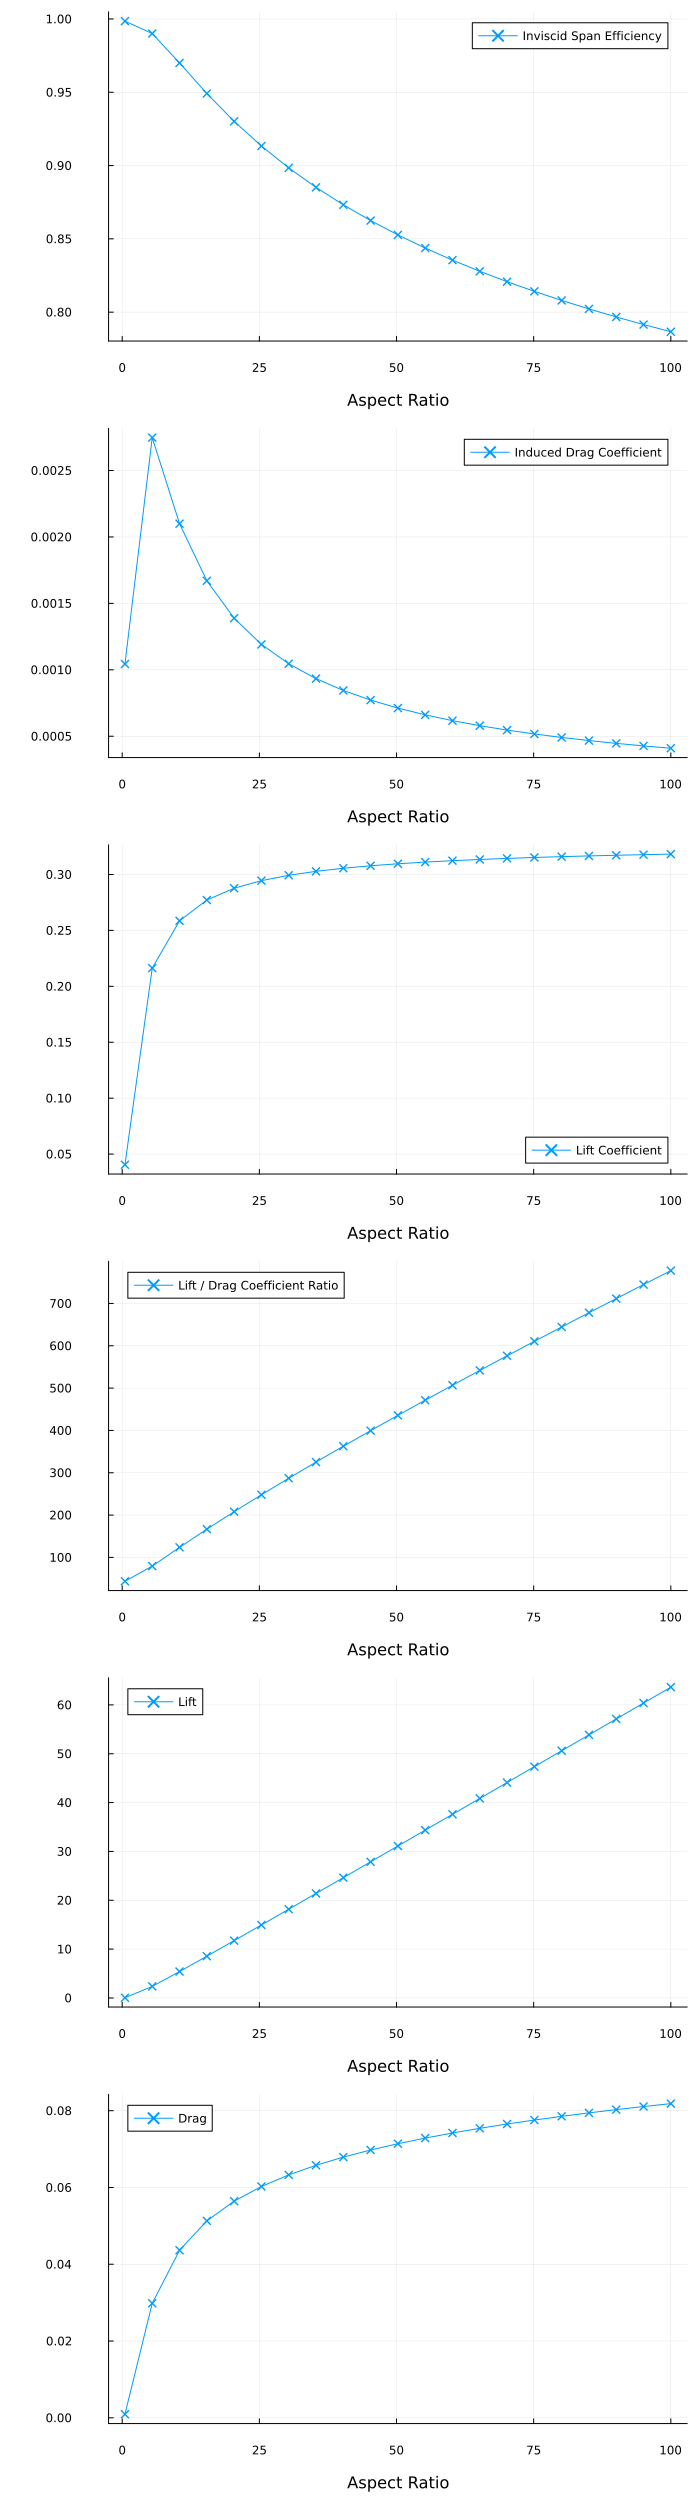

In [4]:
# Define iteration parameters and allocate matrices -------------------------------------------------
min_half_span = 0.5
max_half_span = 100
reiterations = 20
step = (max_half_span - min_half_span) / (reiterations)
AR = zeros(reiterations+1) # aspect ratios 
eff = zeros(reiterations+1) # inviscid span efficiencies
C_Di = zeros(reiterations+1) # induced drag coefficient
C_D = zeros(reiterations+1) # drag coefficient
C_L = zeros(reiterations+1) # lift coefficient
lift_drag_ratio = zeros(reiterations+1) # lift to drag coefficient ratio
L = zeros(reiterations+1) # lift
D = zeros(reiterations+1) # drag


for i in 0:reiterations

    yle = [0.0, min_half_span + i * step] # leading edge y-position (Note that we will sweep through a range of these)
    # Generate Grid / Lifting Surface ------------------------------------------
    # Note that the grid is not needed for analysis, just there for convenience.
    # Also note that we could generate a lifting surface from a pre-existing grid using 'grid_to_surface_panels'.
    # 'mirror' mirrors geometry across the X-Y plane.
    grid, surface = wing_to_surface_panels(xle, yle, zle, chord, theta, phi, ns, nc; fc = fc, spacing_s=spacing_s, spacing_c=spacing_c, mirror=true)
    # Combine all surfaces in a single vector (in this case we only have one surface)
    surfaces = [surface]

    # Define reference parameters ----------------------------------------------
    Sref = ref_area_trap(yle, chord)
    bref = ref_span(yle) # reference span
    ref = Reference(Sref, cref, bref, rref, Vinf)

    # Steady state analysis ----------------------------------------------------
    # performs near-field analysis on each panel unless kwarg 'near_field_analysis' is changed
    # Determines derivatives with respect to freestream variables unless specified through kwarg 'derivatives'
    # kwarg 'symmetric' is not strictly necessary, since by default it is set to false for each surface.
    system = steady_analysis(surfaces, ref, fs; symmetric)

    # Extract force/moment coefficients -----------------------------------------
    # returned in the reference fram specified by kwarg 'frame', with the body being the default reference
    # only returns sensible results if near field analysis was performed on 'system'
    CF, CM = body_forces(system; frame=Wind())
    # extract aerodynamic forces
    CD, CY, CL = CF
    Cl, Cm, Cn = CM
    # Numerical noise often corrupts drag estimates so it is often more accurate to compute drag in the farfield on the Trefftz plane
    CDiff = far_field_drag(system)

    # Save data ---------------------------------------------------------------------
    AR[i+1] = aspect_ratio(yle, chord)
    eff[i+1] = wing_efficiency(CL, CDiff, yle, chord)
    C_Di[i+1] = CDiff
    C_D[i+1] = CD
    C_L[i+1] = CL
    lift_drag_ratio[i+1] = CL / CD
    L[i+1] = force(CL, Sref, Vinf)
    D[i+1] = force(CD, Sref, Vinf)

    # Write VTK first and last iteration
    if i == 0
        write_vtk("low-AR", surfaces; symmetric)
    elseif i == reiterations
        write_vtk("high-AR", surfaces; symmetric)
    end

end

plt = plot(AR, [eff C_Di C_L lift_drag_ratio L D], xlabel="Aspect Ratio", markershape=:x, label=["Inviscid Span Efficiency" "Induced Drag Coefficient" "Lift Coefficient" "Lift / Drag Coefficient Ratio" "Lift" "Drag"], layout=(6,1), leg=:best, size=(700,2500), left_margin=20.0mm)
display(plt)

nothing

<p align=center>
    <img src=".\images\aspect_ratio.png" alt="aspect ratio" height="2000">  
<p>

From the plots we can see a few things. The results for the inviscid span efficiency come from that the comparison we're making isn't really valid. However, we can see that lift and drag both increase as the wing increases in size, which is unsurprising. Looking at coefficients we see that as aspect ratio increase lift coefficient increases and drag coefficient decreases. This can be attributed to a decrease in the fraction of the wing that is significantly affected by the wing-tip vortexes. As a result if we look at the ratio between the two we see that increasing aspect ratio increases the coefficient of lift / coefficient of drag ratio in a nearly linear manner. Therefore, increasing aspect ratio increases efficiency (or - more accurately - lift-drag ratio).

*Note: For the lever arm of the vertical stabilizer, I generated a formula for the approximate mean aerodynamic center as illustrated here using Desmos:*
<p align=center>
    <img src=".\images\desmos.png" alt="aspect ratio" height="300">  
<p>

### Tail Volume vs Stability

For exploring tail volume vs stability I took two different approaches. To understand why I will define horizontal and vertical tail volume where $S$ is referency area, $l$ is moment arm (from center of gravity of aircraft to mean aerodynamic center of either the horizontal or vertical stabilizer), $\bar{c}$ is reference chord, and $b$ is span. The subscripts refer to either horizontal or vertical tail respectively rather than the wing:
$$
\begin{align*}
V_{TH} &= \frac{S_{TH} l_{TH}}{S \bar{c}} \\
V_{TV} &= \frac{S_{TV} l_{TV}}{S b}
\end{align*}
$$

My first approach was to explore the effect of changing just the position of the stabilizers to adjust the tail volume. However, I realized that this method does not allow holding either vertical or horizontal tail volumes to be constant. My second approach (which proved more useful) was to sweep acrost a range of areas for the horizontal or vertical stabilizers. Here's my code for the second approach, first holding vertical stabilizer dimensions constant:

In [5]:
using VortexLattice

# wing
xle = [0.0, 0.2]
yle = [0.0, 5.0]
zle = [0.0, 0.0]
chord = [1.0, 0.6]
theta = [2.0*pi/180, 2.0*pi/180]
phi = [0.0, 0.0]
fc = fill((xc) -> 0, 2) # camberline function for each section
ns = 12
nc = 6
spacing_s = Sine()
spacing_c = Uniform()
mirror = true

# generate surface panels for wing
wgrid, wing = wing_to_surface_panels(xle, yle, zle, chord, theta, phi, ns, nc; mirror=mirror, fc = fc, spacing_s=spacing_s, spacing_c=spacing_c)

# reference geometry
Sref = ref_area_trap(yle, chord)
cref = ref_chord(chord)
bref = ref_span(yle)
rref = [cref, 0.0, 0.0]
Vinf = 1.0
ref = Reference(Sref, cref, bref, rref, Vinf)

# freestream
alpha = 5.0*pi/180
beta = 0.0
Omega = [0.0; 0.0; 0.0]
fs = Freestream(Vinf, alpha, beta, Omega)

symmetric = [false, false, false]

trans = [10.0, 0.0, 0.0]

# define iteration parameters
iterations = 20 # number of iterations
min_size_v = 1.0 # CONSTANT magnification of vertical stabilizer linear dimensions
max_size_v = 1.0 # CONSTANT magnification of vertical stabilizer linear dimensions
min_size_h = 0.5 # magnification of horizontal stabilizer linear dimensions
max_size_h = 2.5 # magnification of horizontal stabilizer linear dimensions

    # horizontal stabilizer initial values
    xle_h = [0.0, 0.14]
    yle_h = [0.0, 2.0]
    zle_h = [0.0, 0.0]
    chord_h = [0.7, 0.42]
    theta_h = [0.0, 0.0]
    phi_h = [0.0, 0.0]
    fc_h = fill((xc) -> 0, 2) #camberline function for each section
    ns_h = 6
    nc_h = 3
    spacing_s_h = Sine()
    spacing_c_h = Uniform()
    mirror_h = true

    # create matrix of equally spaced values to iterate across for each variable aspect of horizontal stabilizer geometry
    xle_h_steps = get_steps_vec(min_size_h * xle_h, max_size_h * xle_h, iterations)
    yle_h_steps = get_steps_vec(min_size_h * yle_h, max_size_h * yle_h, iterations)
    chord_h_steps = get_steps_vec(min_size_h * chord_h, max_size_h * chord_h, iterations)
    ns_h_steps = get_steps_num(min_size_h * ns_h, max_size_h * ns_h, iterations)
    nc_h_steps = get_steps_num(min_size_h * nc_h, max_size_h * nc_h, iterations)

    # vertical stabilizer initial values
    xle_v = [0.0, 0.14]
    yle_v = [0.0, 0.0]
    zle_v = [0.0, 2.0]
    chord_v = [0.7, 0.42]
    theta_v = [0.0, 0.0]
    phi_v = [0.0, 0.0]
    fc_v = fill((xc) -> 0, 2) #camberline function for each section
    ns_v = 5
    nc_v = 3
    spacing_s_v = Uniform()
    spacing_c_v = Uniform()
    mirror_v = false

    # create matrix of equally spaced values to iterate across for each variable aspect of vertical stabilizer geometry
    xle_v_steps = get_steps_vec(min_size_v * xle_v, max_size_v * xle_v, iterations)
    zle_v_steps = get_steps_vec(min_size_v * zle_v, max_size_v * zle_v, iterations)
    chord_v_steps = get_steps_vec(min_size_v * chord_v, max_size_v * chord_v, iterations)
    ns_v_steps = get_steps_num(min_size_v * ns_v, max_size_v * ns_v, iterations)
    nc_v_steps = get_steps_num(min_size_v * nc_v, max_size_v * nc_v, iterations)

# initialize matrices for data
labels = ["V_th" "V_tv" "CDa" "CYa" "CLa" "Cla_" "Cma" "Cna" "CDb" "CYb" "CLb" "Clb_" "Cmb" "Cnb" "CDp" "CYp" "CLp" "Clp_" "Cmp" "Cnp" "CDq" "CYq" "CLq" "Clq_" "Cmq" "Cnq" "CDr" "CYr" "CLr" "Clr_" "Cmr" "Cnr"]
data = zeros(iterations,32)

for i in 1:iterations

    # horizontal stabilizer
    xle_h = xle_h_steps[:, i]
    yle_h = yle_h_steps[:, i]
    chord_h = chord_h_steps[:, i]
    ns_h = ns_h_steps[i]
    nc_h = nc_h_steps[i]

    # vertical stabilizer
    xle_h = xle_v_steps[:, i]
    zle_v = zle_v_steps[:, i]
    chord_v = chord_v_steps[:, i]
    ns_v = ns_v_steps[i]
    nc_v = nc_v_steps[i]

    # generate surface panels for horizontal tail
    hgrid, htail = wing_to_surface_panels(xle_h, yle_h, zle_h, chord_h, theta_h, phi_h, ns_h, nc_h;
                   mirror=mirror_h, fc=fc_h, spacing_s=spacing_s_h, spacing_c=spacing_c_h)
    VortexLattice.translate!(hgrid, trans)
    VortexLattice.translate!(htail, trans)

    # generate surface panels for vertical tail
    vgrid, vtail = wing_to_surface_panels(xle_v, yle_v, zle_v, chord_v, theta_v, phi_v, ns_v, nc_v;
                   mirror=mirror_v, fc=fc_v, spacing_s=spacing_s_v, spacing_c=spacing_c_v)
    VortexLattice.translate!(vgrid, trans)
    VortexLattice.translate!(vtail, trans)

    grids = [wgrid, hgrid, vgrid]
    surfaces = [wing, htail, vtail]
    surface_id = [1, 2, 3]

    system = steady_analysis(surfaces, ref, fs; symmetric=symmetric, surface_id=surface_id)

    properties = get_surface_properties(system)

    # Extract stability derivatives -------------------------------------------------
    # Note that for sensible results, near-field analysis must have been performed
    dCFs, dCMs = stability_derivatives(system)
    # traditional names for each stability derivative
    CDa, CYa, CLa = dCFs.alpha
    Cla, Cma, Cna = dCMs.alpha
    CDb, CYb, CLb = dCFs.beta
    Clb, Cmb, Cnb = dCMs.beta
    CDp, CYp, CLp = dCFs.p
    Clp, Cmp, Cnp = dCMs.p
    CDq, CYq, CLq = dCFs.q
    Clq, Cmq, Cnq = dCMs.q
    CDr, CYr, CLr = dCFs.r
    Clr, Cmr, Cnr = dCMs.r
    V_th = tail_volume_h(yle, yle_h, chord, chord_h, trans, rref)
    V_tv = tail_volume_v(yle, xle_v, zle_v, chord, chord_v, trans, rref)

    # save data for current iteration
    data[i, :] = [V_th V_tv CDa CYa CLa Cla Cma Cna CDb CYb CLb Clb Cmb Cnb CDp CYp CLp Clp Cmp Cnp CDq CYq CLq Clq Cmq Cnq CDr CYr CLr Clr Cmr Cnr]

    # write VTK file for first and last iterations
    if i ==1
        write_vtk("wing-tail-small-h", surfaces, properties; symmetric)
    elseif i == iterations
        write_vtk("wing-tail-large-h", surfaces, properties; symmetric)
        global system = system
    end

end

# combine data with labels
data_l = vcat(labels, data)

# include script for saving all of the plots for each stability derivative with respect to horizontal or vertical tail volume
include("stability_plots.jl")
generate_plots(labels, data, "horizontal_scaling_only")

nothing

skip success
skip success
plot V_th vs CDa success
plot V_tv vs CDa success
plot V_th vs CYa success
plot V_tv vs CYa success


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194


plot V_th vs CLa success
plot V_tv vs CLa success
plot V_th vs Cla_ success
plot V_tv vs Cla_ success
plot V_th vs Cma success
plot V_tv vs Cma success


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194


plot V_th vs Cna success
plot V_tv vs Cna success
plot V_th vs CDb success


...

plot V_tv vs CDr success
plot V_th vs CYr success
plot V_tv vs CYr success
plot V_th vs CLr success


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194


plot V_tv vs CLr success
plot V_th vs Clr_ success
plot V_tv vs Clr_ success

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194



plot V_th vs Cmr success
plot V_tv vs Cmr success
plot V_th vs Cnr success
plot V_tv vs Cnr success


And then repeated for holding horizontal tail volume constant:

In [6]:
# define iteration parameters
iterations = 20 # number of iterations
min_size_v = 0.5 # magnification of vertical stabilizer linear dimensions
max_size_v = 2.5 # magnification of vertical stabilizer linear dimensions
min_size_h = 1.0 # CONSTANT magnification of horizontal stabilizer linear dimensions
max_size_h = 1.0 # CONSTANT magnification of horizontal stabilizer linear dimensions

# create matrix of equally spaced values to iterate across for each variable aspect of horizontal stabilizer geometry
xle_h_steps = get_steps_vec(min_size_h * xle_h, max_size_h * xle_h, iterations)
yle_h_steps = get_steps_vec(min_size_h * yle_h, max_size_h * yle_h, iterations)
chord_h_steps = get_steps_vec(min_size_h * chord_h, max_size_h * chord_h, iterations)
ns_h_steps = get_steps_num(min_size_h * ns_h, max_size_h * ns_h, iterations)
nc_h_steps = get_steps_num(min_size_h * nc_h, max_size_h * nc_h, iterations)

# create matrix of equally spaced values to iterate across for each variable aspect of vertical stabilizer geometry
xle_v_steps = get_steps_vec(min_size_v * xle_v, max_size_v * xle_v, iterations)
zle_v_steps = get_steps_vec(min_size_v * zle_v, max_size_v * zle_v, iterations)
chord_v_steps = get_steps_vec(min_size_v * chord_v, max_size_v * chord_v, iterations)
ns_v_steps = get_steps_num(min_size_v * ns_v, max_size_v * ns_v, iterations)
nc_v_steps = get_steps_num(min_size_v * nc_v, max_size_v * nc_v, iterations)

# initialize matrices for data
labels = ["V_th" "V_tv" "CDa" "CYa" "CLa" "Cla_" "Cma" "Cna" "CDb" "CYb" "CLb" "Clb_" "Cmb" "Cnb" "CDp" "CYp" "CLp" "Clp_" "Cmp" "Cnp" "CDq" "CYq" "CLq" "Clq_" "Cmq" "Cnq" "CDr" "CYr" "CLr" "Clr_" "Cmr" "Cnr"]
data = zeros(iterations,32)

for i in 1:iterations

    # horizontal stabilizer
    xle_h = xle_h_steps[:, i]
    yle_h = yle_h_steps[:, i]
    chord_h = chord_h_steps[:, i]
    ns_h = ns_h_steps[i]
    nc_h = nc_h_steps[i]

    # vertical stabilizer
    xle_h = xle_v_steps[:, i]
    zle_v = zle_v_steps[:, i]
    chord_v = chord_v_steps[:, i]
    ns_v = ns_v_steps[i]
    nc_v = nc_v_steps[i]

    # generate surface panels for horizontal tail
    hgrid, htail = wing_to_surface_panels(xle_h, yle_h, zle_h, chord_h, theta_h, phi_h, ns_h, nc_h;
                   mirror=mirror_h, fc=fc_h, spacing_s=spacing_s_h, spacing_c=spacing_c_h)
    VortexLattice.translate!(hgrid, trans)
    VortexLattice.translate!(htail, trans)

    # generate surface panels for vertical tail
    vgrid, vtail = wing_to_surface_panels(xle_v, yle_v, zle_v, chord_v, theta_v, phi_v, ns_v, nc_v;
                   mirror=mirror_v, fc=fc_v, spacing_s=spacing_s_v, spacing_c=spacing_c_v)
    VortexLattice.translate!(vgrid, trans)
    VortexLattice.translate!(vtail, trans)

    grids = [wgrid, hgrid, vgrid]
    surfaces = [wing, htail, vtail]
    surface_id = [1, 2, 3]

    system = steady_analysis(surfaces, ref, fs; symmetric=symmetric, surface_id=surface_id)

    properties = get_surface_properties(system)

    # Extract stability derivatives -------------------------------------------------
    # Note that for sensible results, near-field analysis must have been performed
    dCFs, dCMs = stability_derivatives(system)
    # traditional names for each stability derivative
    CDa, CYa, CLa = dCFs.alpha
    Cla, Cma, Cna = dCMs.alpha
    CDb, CYb, CLb = dCFs.beta
    Clb, Cmb, Cnb = dCMs.beta
    CDp, CYp, CLp = dCFs.p
    Clp, Cmp, Cnp = dCMs.p
    CDq, CYq, CLq = dCFs.q
    Clq, Cmq, Cnq = dCMs.q
    CDr, CYr, CLr = dCFs.r
    Clr, Cmr, Cnr = dCMs.r
    V_th = tail_volume_h(yle, yle_h, chord, chord_h, trans, rref)
    V_tv = tail_volume_v(yle, xle_v, zle_v, chord, chord_v, trans, rref)

    # save data for current iteration
    data[i, :] = [V_th V_tv CDa CYa CLa Cla Cma Cna CDb CYb CLb Clb Cmb Cnb CDp CYp CLp Clp Cmp Cnp CDq CYq CLq Clq Cmq Cnq CDr CYr CLr Clr Cmr Cnr]

    # write VTK file for first and last iterations
    if i ==1
        write_vtk("wing-tail-small-v", surfaces, properties; symmetric)
    elseif i == iterations
        write_vtk("wing-tail-large-v", surfaces, properties; symmetric)
        global system = system
    end

end

# combine data with labels
data_l = vcat(labels, data)

# include script for saving all of the plots for each stability derivative with respect to horizontal or vertical tail volume
include("stability_plots.jl")
generate_plots(labels, data, "vertical_scaling_only")

nothing

skip success
skip success
plot V_th vs CDa success
plot V_tv vs CDa success


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194


plot V_th vs CYa success
plot V_tv vs CYa success
plot V_th vs CLa success


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194


plot V_tv vs CLa success
plot V_th vs Cla_ success
plot V_tv vs Cla_ success
plot V_th vs Cma success
plot V_tv vs Cma success
plot V_th vs Cna success


...

plot V_tv vs CDp success
plot V_th vs CYp success
plot V_tv vs CYp success
plot V_th vs CLp success


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194


plot V_tv vs CLp success
plot V_th vs Clp_ success
plot V_tv vs Clp_ success
plot V_th vs Cmp success
plot V_tv vs Cmp success
plot V_th vs Cnp success
plot V_tv vs Cnp success
plot V_th vs CDq success
plot V_tv vs CDq success
plot V_th vs CYq success
plot V_tv vs CYq success
plot V_th vs CLq success
plot V_tv vs CLq success
plot V_th vs Clq_ success
plot V_tv vs Clq_ success
plot V_th vs Cmq success
plot V_tv vs Cmq success
plot V_th vs Cnq success
plot V_tv vs Cnq success
plot V_th vs CDr success
plot V_tv vs CDr success
plot V_th vs CYr success


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\samia\.julia\packages\PlotUtils\8mrSm\src\ticks.jl:194


plot V_tv vs CYr success
plot V_th vs CLr success
plot V_tv vs CLr success
plot V_th vs Clr_ success
plot V_tv vs Clr_ success
plot V_th vs Cmr success
plot V_tv vs Cmr success
plot V_th vs Cnr success
plot V_tv vs Cnr success


Here's a few of the plots that are generated and a table of the results:

<p align=center>
    <img src=".\images\horizontal_scaling\Vth_v_CDa.png" height="250">
    <img src=".\images\horizontal_scaling\Vth_v_CLp.png" height="250">
    <img src=".\images\horizontal_scaling\Vtv_v_CDr.png" height="250">
    <img src=".\images\vertical_scaling\Vth_v_CDp.png" height="250">
    <img src=".\images\vertical_scaling\Vtv_v_CDa.png" height="250">
    <img src=".\images\vertical_scaling\Vtv_v_CDp.png" height="250">
    <img src=".\images\table_chart.png" height="400">
<p>

In the table the "V_th" column represents the charts for when *only horizontal tail volume is scaled*. You can see in the third chart above an example of how $V_{tv}$ stays constant as expected and the results are not useful. The "V_tv" column of the table represents when *just the vertical tail volume is scaled*. You can see an example in the fourth chart above of how $V_{th}$ stays constant as expected and the results are not useful. The table has highlighted in red the most notable results with some other noteable results marked in yellow. Approximate percent changes are also included for convenience in analysis. Where an "x" is marked, the data is just numerical noise as in the second and sixth charts above.

<p align=center>
    <img src=".\images\signs.png" height="250">
<p>

**Notes on Horizontal Tail Volume**  
We can see from the results that *adjusting only the area of the horizontal stabilizer* (see images below) results in the following:
- For small positive disturbances in alpha there will be greater lift and drag. Additionally the larger horizontal stabilizer's lift will generate a negative pitching moment on the airframe. This can be seen directly from the lift and pitching moments with respect to pitch rate. 
- Since the horizontal stabilizer is symmetric, it will resist rolling moments. This is seen with respect to beta, where initially the vertical stabilizer may generate a rolling moment, but the horizontal stabilizer resists this. This is also seen more directly with the negative sign with respect to roll rate. 
- It's worth noting that when the aircraft rolls, the wing as well as horizontal stabilizers will resist rolling, but also generate 'lift' in the 'side force direction'. Additionally, the 'lift' from the tail (when rolled in the positive direction) will produce a negative yawing moment on the airframe. 

<p align="center">
    <img src="./images/small_h.png" height=250>
    <img src="./images/large_h.png" height=250>
<p>


**Notes on Vertical Tail Volume**  
From *adjusting only the area of the vertical stabilizer* (see images below) we find the following:
- For a positive sideslip angle the vertical stabilizer generates a negative side force, rolling moment, and yawing moment. This makes sense since the sideslip angle beta is essentially acting as the angle of attack for the vertical stabilizer, so for a positive sideslip angle (see figure above) it would generate the corresponding side force and yawing moment. The rolling moment is explained because the vertical stabilizer is not symmetric, so any 'lift' generated by the sideslip angle would create a negative rolling moment. 
- Intuitively, the vertical stabilizer (like the horizontal stabilizer) resists rolling as seen from the graph of Clp.
- Some of the other results with respect to roll rate can be explained by the fact the horizontal tail when rolled generates lift that produces a positive sideforce and negative yawing moment (see notes on horizontal tail volume), while the horizontal tail when quickly rolled in the positive direction would tend to generate a negative sideforce and positive yawing moment. 
    - From this we can gather that there is likely a particular ratio between the horizontal and vertical tail volume ratios that would generate no yawing moment or sideforce with respect to roll rate. This could be an area for future study.
- With respect to yaw rate we see results opposite from with respect to beta. This is expected since a positive yaw would create a negative sideslip angle. 

<p align="center">
    <img src="./images/small_v.png" height=250>
    <img src="./images/large_v.png" height=250>
<p>

There's definitely a lot to unpack here, but the big takeaway is that generally the signs for all of these derivative are negative (aside from lift and drag for the horizontal stabilizer obviously, as well as a few others). This means that the stabilizers tend to correct instability, which is good. In other words the stabilizers stabilize, who would have guessed? Another takeaway (for future research) is that there must be some ratio between the vertical and horizontal stabilizers as well as the wing that would provide certain desireable effects (such as no sideforce or yawing moment with respect to roll rate, or just the right amount of negative pitching moment with respect to alpha). 

### Angle of Attack vs Lift Coefficient: Limitations of VLM

To examine angle of attack vs lift coefficient I ran an analysis similar to the 'getting started' example in the documentation, except repeated across a wide range of angles of attacks (0 degrees to 360 degrees). I then saved a matrix of the results and plotted them:



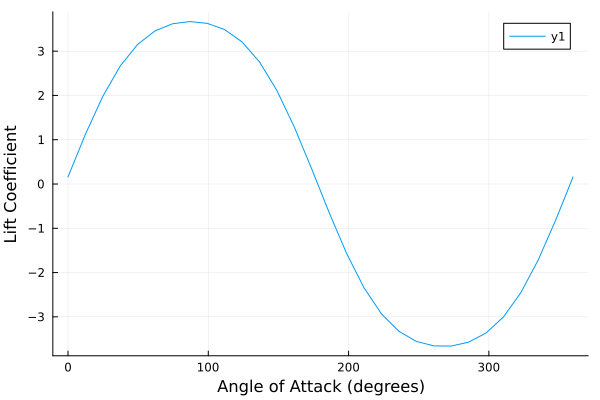

In [7]:
# Define Panels ------------------------------------------------------------
ns = 20 # number of spanwise panels
nc = 8  # number of chordwise panels

# Define freestream -------------------------------------------------------
beta = 0.0 # sideslip angle
Omega = [0.0, 0.0, 0.0] # rotational velocity around the reference location
# we can model other half of wing using 'symmetric = true', but it would give incorect lateral stability, so we instead already mirrored our geometry across X-Z plane
symmetric = false

# Define Geometry --------------------------------------------------------
xle = [0.0, 0.4] # leading edge x-position
yle = [0.0, 7.5] # leading edge y-position
zle = [0.0, 0.0] # leading edge z-position
chord = [2.2, 1.8] # chord length [root, tip]
theta = [2.0*pi/180, 2.0*pi/180] # twist (in radians)
phi = [0.0, 0.0] # section rotation about the x-axis
fc = fill((xc) -> 0, 2) # camberline function for each section (y/c = f(x/c))

# Define constant reference geometry --------------------------------------
cref = ref_chord(chord)  # reference chord
rref = center_of_g(chord) # reference location for rotations/moments (typically the c.g.)
Vinf = 1.0 # reference velocity 

# leading edge y-position (Note that we will sweep through a range of these)
# Generate Grid / Lifting Surface ------------------------------------------
# Note that the grid is not needed for analysis, just there for convenience.
# Also note that we could generate a lifting surface from a pre-existing grid using 'grid_to_surface_panels'.
# 'mirror' mirrors geometry across the X-Y plane.
grid, surface = wing_to_surface_panels(xle, yle, zle, chord, theta, phi, ns, nc; fc = fc, spacing_s=spacing_s, spacing_c=spacing_c, mirror=true)
# Combine all surfaces in a single vector (in this case we only have one surface)
surfaces = [surface]

# Define reference parameters ----------------------------------------------
Sref = ref_area_trap(yle, chord) # reference area
bref = ref_span(yle) # average (reference) span
ref = Reference(Sref, cref, bref, rref, Vinf)


# Define iteration parameters and allocate matrices -------------------------------------------------
iterations = 30 # number of iterations
alpha_min = 0.0*pi/180 # min angle of attack
alpha_max = 360.0*pi/180 # max angle of attack
alpha_step = get_step_float(alpha_min, alpha_max, iterations) # create a vector of 20 equally spaced alpha angles from max to min.
data = zeros(iterations, 2) # allocate matrix to hold data

for i in 1:iterations

    fs = Freestream(Vinf, alpha_step[i], beta, Omega) # define freestream using alpha

    # Steady state analysis ----------------------------------------------------
    # performs near-field analysis on each panel unless kwarg 'near_field_analysis' is changed
    # Determines derivatives with respect to freestream variables unless specified through kwarg 'derivatives'
    # kwarg 'symmetric' is not strictly necessary, since by default it is set to false for each surface.
    system = steady_analysis(surfaces, ref, fs; symmetric=symmetric)

    # Extract force/moment coefficients -----------------------------------------
    # returned in the reference frame specified by kwarg 'frame', with the body being the default reference
    # only returns sensible results if near field analysis was performed on 'system'
    CF, CM = body_forces(system; frame=Wind())

    # extract aerodynamic forces
    CD, CY, CL = CF
    Cl, Cm, Cn = CM
    # Numerical noise often corrupts drag estimates so it is often more accurate to compute drag in the farfield on the Trefftz plane
    CDiff = far_field_drag(system)

    # save data to data matrix
    data[i, 1] = alpha_step[i] * 180 / pi
    data[i, 2] = CL

end

# plot data and save results (replacing file of same name if it exists)
plt = plot(data[:,1], data[:,2], xlabel="Angle of Attack (degrees)", ylabel="Lift Coefficient", leg=:best)

Interesting! How do we explain these results? We know that most airfoils stall before 30 degrees after all. Let's remember that for VLM we make some important assumptions:
- Inviscid, irrotational flow.
- Infinitely thin wing.
- **Small angle of attack.**
- Kutta condition.

If we remember *the fundamental equation of lifting line theory*:
$$
\begin{align*}
c_l &= m(\alpha - \alpha_0 - \alpha_i) \\
\implies c_l(y) = \frac{\Gamma(y)}{\frac{1}{2} V(y)c(y)} &= m(y)\left( \alpha(y) - \alpha_0(y) - \tan^{-1}\left( \frac{1}{4 \pi V(y)} \int_{-b/2}^{b/2} \frac{\gamma(y')dy'}{y-y'} \right) \right)
\end{align*}
$$

Note that this gives that **the lift coefficient is solely dependent on the effective angle of attack**. This comes from the assumption that for each lift coefficient calculation the airfoil is in the linear region (NO STALL, or in other words, low angle of attack). Therefore, we should expect that for high angles of attack our results are going to be non-physical. This is clear from the graph above. I would have expected an almost linear graph where angle of attack directly correlates positively to lift coefficient (which we do in fact see for small angles of attack; see figure below). The sine curve shape of the graph is probably due to some sort of remnant produced by the code in VortexLattice.jl. Searching for this is beyond the scope of this assignment, but could be done. 

We would also expect some discrepancies to appear if we were analyzing an unusually thick wing, since that's another assumption of VLM. And so forth for the other assumptions. 

The main takeaway is that VLM only really works for thin wings at small angles of attack (see figure below), however it is very versatile and inexpensive computationally. 

<p align="center">
    <img src="./images/alpha_v_CL_small.png" height=250>
<p>

## Conclusion

VLM is an effective tool for analyzing airframes with thin wings at small angles of attack. This is a common situation for aircraft, and therefore very useful and applicable. 

Wings with high aspect ratios are more efficient (in terms of lift to drag ratio). However, it is beyond the scope of this assignment to explore structural and practical limitations.

Higher tail volume ratios increase aircraft stability. However, stability that is too high would make an aircraft unmaneuverable. Additionally, higher horizontal tail volume generates a negative pitching moment, which is desireable to an extent. Excess would prove to make an aircraft unflyable. There is some balance to be struck that provides desireable attributes for the aerodynamic behavior for particular airframes. There is much more work that could be done to optimize aircraft tail volume for some given parametersm, but that is beyond the scope of this assignment. 

Vortex Lattice method is effective for low angles of attack, but has no method for predicting stall. Therefore at high angles of attack we see non-physical results, some of which may be a remnant of the code in VortexLattice.jl. At low angle of attack we observe a positive almost-linear correlation between angle of attack and lift coefficient, which is expected from the fundamental equation of lifting line theory.

## Works Cited

Ning, Andrew, "Flight Vehicle Design" (2018). Books. 26.  

Ning, Andrew, "Computational Aerodynamics" (2022). Books. 
